In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from IPython.display import display, HTML
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/My Drive/Colab Notebooks/Glovo/Datos_Glovo.xlsx'
df = pd.read_excel(file_path)
df.head()

,Tipo,Fecha,Numero Factura,Base imponible,IVA,Total Factura,Propina,Total Facturado
0,Factura partner,6/11/2024,ES-WKUK2Y6-000001/24,3.00,0.63,3.63,0.0,3.63
1,Factura partner,6/11/2024,ES-WKUK2Y6-000002/24,4.42,0.93,5.35,0.0,5.35
2,Factura cliente,6/11/2024,ES-WKUK2Y6-000003/24,3.30,0.69,3.99,0.0,3.99
3,Factura partner,6/11/2024,ES-WKUK2Y6-000004/24,1.25,0.26,1.51,0.0,1.51
4,Factura cliente,6/11/2024,ES-WKUK2Y6-000005/24,2.88,0.61,3.49,0.0,3.49


In [4]:
df['Fecha'] = pd.to_datetime(df['Fecha'], dayfirst=True)

In [5]:
df.head()

,Tipo,Fecha,Numero Factura,Base imponible,IVA,Total Factura,Propina,Total Facturado
0,Factura partner,2024-11-06,ES-WKUK2Y6-000001/24,3.00,0.63,3.63,0.0,3.63
1,Factura partner,2024-11-06,ES-WKUK2Y6-000002/24,4.42,0.93,5.35,0.0,5.35
2,Factura cliente,2024-11-06,ES-WKUK2Y6-000003/24,3.30,0.69,3.99,0.0,3.99
3,Factura partner,2024-11-06,ES-WKUK2Y6-000004/24,1.25,0.26,1.51,0.0,1.51
4,Factura cliente,2024-11-06,ES-WKUK2Y6-000005/24,2.88,0.61,3.49,0.0,3.49


In [6]:
df['Año'] = df['Fecha'].dt.year
df['Mes'] = df['Fecha'].dt.month

In [12]:
ventas_por_mes = df.groupby(["Año","Mes"])["Total Facturado"].sum()

In [13]:
ventas_por_dia = df.groupby("Fecha")["Total Facturado"].sum()
media_ventas_diaria = ventas_por_dia.mean()
print("Media de ventas diaria:", media_ventas_diaria)

Media de ventas diaria: 44.99400000000001


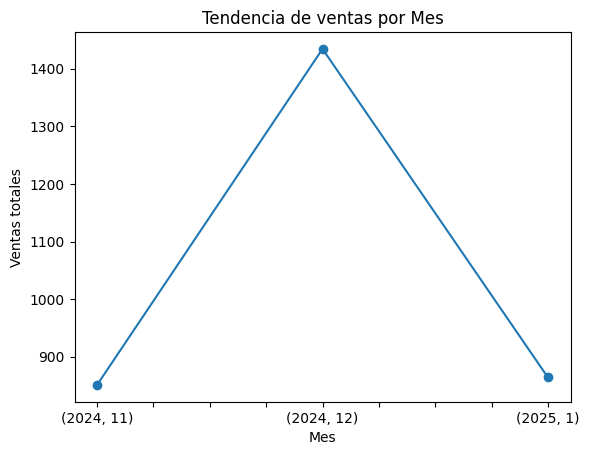

In [14]:
ventas_por_mes.plot(kind="line", marker="o")
plt.xlabel("Mes")
plt.ylabel("Ventas totales")
plt.title("Tendencia de ventas por Mes")
plt.show()

In [15]:
ventas_por_mes_año = df.groupby(["Año", "Mes"])["Total Facturado"].sum().reset_index()

In [16]:
print(ventas_por_mes_año)

    Año  Mes  Total Facturado
0  2024   11           851.10
1  2024   12          1434.48
2  2025    1           864.00


In [17]:
media_ventas = ventas_por_mes_año["Total Facturado"].mean()
print("Media de ventas:", media_ventas)

Media de ventas: 1049.86


In [18]:
ventas_por_mes.mean()

1049.86

In [19]:
ventas_por_mes.median()

864.0

In [20]:
ventas_por_mes.std()

333.1531341590531

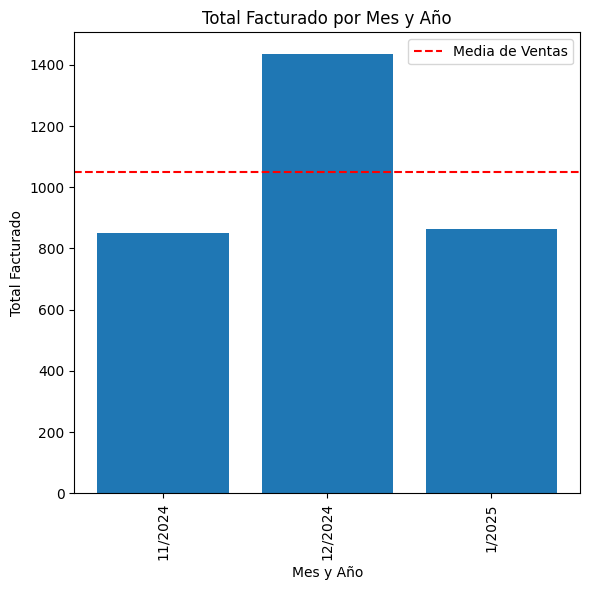

In [21]:
plt.figure(figsize=(6, 6))
plt.bar(ventas_por_mes_año.index, ventas_por_mes_año["Total Facturado"])
plt.xlabel("Mes y Año")
plt.ylabel("Total Facturado")
plt.title("Total Facturado por Mes y Año")
plt.xticks(ventas_por_mes_año.index, ventas_por_mes_año["Mes"].astype(str) + "/" + ventas_por_mes_año["Año"].astype(str), rotation=90)

# Calcular la media de las ventas
media_ventas = ventas_por_mes_año["Total Facturado"].mean()

# Agregar una línea horizontal para la media
plt.axhline(y=media_ventas, color='r', linestyle='--', label='Media de Ventas')

plt.legend() # Mostrar leyenda para identificar las líneas
plt.tight_layout()
plt.show()

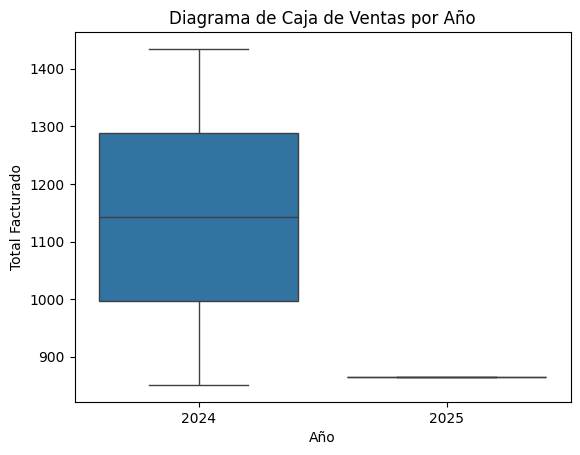

In [22]:
sns.boxplot(x="Año", y="Total Facturado", data=ventas_por_mes_año)
plt.title("Diagrama de Caja de Ventas por Año")
plt.show()

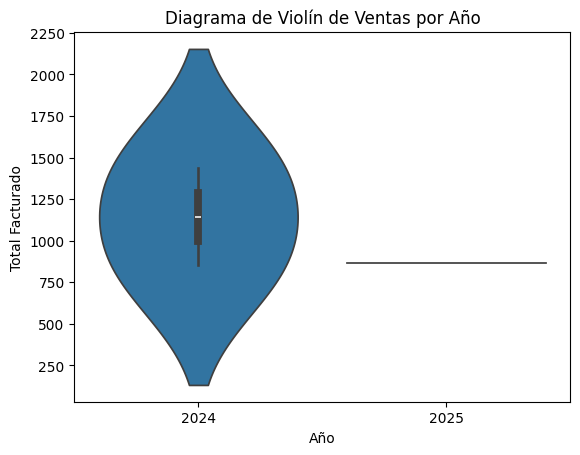

In [23]:
sns.violinplot(x="Año", y="Total Facturado", data=ventas_por_mes_año)
plt.title("Diagrama de Violín de Ventas por Año")
plt.show()

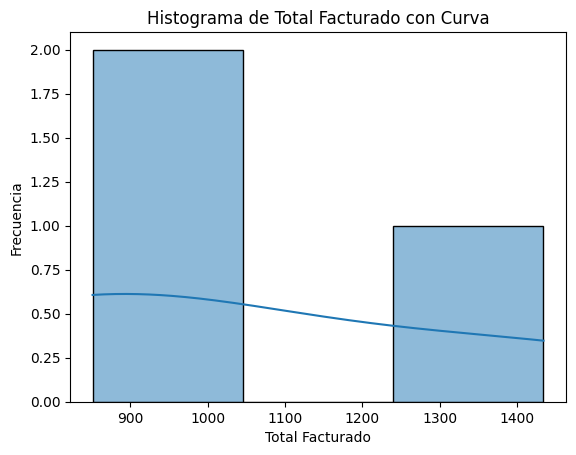

In [24]:
sns.histplot(ventas_por_mes_año["Total Facturado"], kde=True)  # kde=True adds the curve

plt.xlabel("Total Facturado")
plt.ylabel("Frecuencia")
plt.title("Histograma de Total Facturado con Curva")

plt.show()

In [25]:
# Agrupar por fecha y sumar las ventas diarias
ventas_por_dia = df.groupby("Fecha")["Total Facturado"].sum()

# Medidas de tendencia central
media = ventas_por_dia.mean()
mediana = ventas_por_dia.median()
moda = ventas_por_dia.mode()[0]  # La moda puede tener varios valores, se toma el primero

# Media móvil (ventana de 7 días)
media_movil = ventas_por_dia.rolling(window=7, center=True).mean()

# Media móvil exponencial (factor de suavizado 0.2)
media_movil_exp = ventas_por_dia.ewm(alpha=0.2).mean()

# Medidas de dispersión
varianza = ventas_por_dia.var()
desviacion_estandar = ventas_por_dia.std()
coeficiente_variacion = desviacion_estandar / media
rango = ventas_por_dia.max() - ventas_por_dia.min()
rango_intercuartil = ventas_por_dia.quantile(0.75) - ventas_por_dia.quantile(0.25)

# Percentil 90
percentil_90 = ventas_por_dia.quantile(0.90)

# Crear un DataFrame con los resultados
resumen_estadistico = pd.DataFrame({
    "Media": [media],
    "Mediana": [mediana],
    "Moda": [moda],
    "Varianza": [varianza],
    "Desviación Estándar": [desviacion_estandar],
    "Coef. Variación": [coeficiente_variacion],
    "Rango": [rango],
    "Rango Intercuartil": [rango_intercuartil],
    "Percentil 90": [percentil_90]
})

# Mostrar el resumen
print(resumen_estadistico)

    Media  Mediana   Moda    Varianza  Desviación Estándar  Coef. Variación  \
0  44.994   49.125  52.33  407.324937            20.182293         0.448555   

   Rango  Rango Intercuartil  Percentil 90  
0  81.53              30.045        65.733  


In [26]:
# ... (Your existing code to calculate statistical measures) ...

# Crear un DataFrame con los resultados
resumen_estadistico = pd.DataFrame({
    "Media": [media],
    "Mediana": [mediana],
    "Moda": [moda],
    "Varianza": [varianza],
    "Desviación Estándar": [desviacion_estandar],
    "Coef. Variación": [coeficiente_variacion],
    "Rango": [rango],
    "Rango Intercuartil": [rango_intercuartil],
    "Percentil 90": [percentil_90]
})

# Mostrar el resumen en una tabla con formato HTML
display(HTML(resumen_estadistico.to_html(index=False)))

Media,Mediana,Moda,Varianza,Desviación Estándar,Coef. Variación,Rango,Rango Intercuartil,Percentil 90
44.994,49.125,52.33,407.324937,20.182293,0.448555,81.53,30.045,65.733


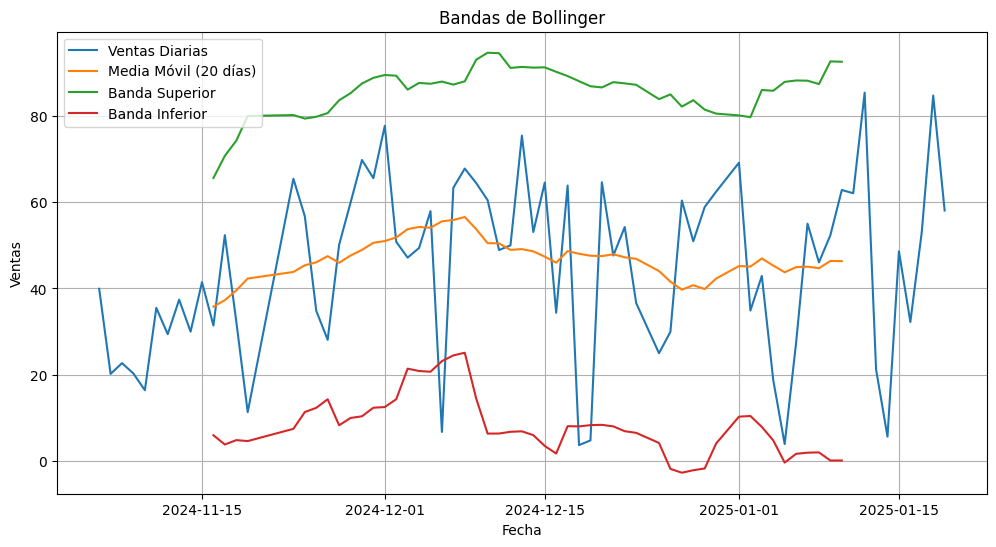

In [27]:
# Asumiendo que 'ventas_por_dia' contiene las ventas diarias
# (como se calculó en tu código anterior)

# Calcular la media móvil (ventana de 20 días, por ejemplo)
media_movil = ventas_por_dia.rolling(window=20, center=True).mean()

# Calcular la desviación estándar móvil (ventana de 20 días)
desviacion_estandar = ventas_por_dia.rolling(window=20, center=True).std()

# Calcular las bandas superior e inferior (2 desviaciones estándar)
banda_superior = media_movil + 2 * desviacion_estandar
banda_inferior = media_movil - 2 * desviacion_estandar

# Crear el gráfico
plt.figure(figsize=(12, 6))
plt.plot(ventas_por_dia.index, ventas_por_dia, label='Ventas Diarias')
plt.plot(media_movil.index, media_movil, label='Media Móvil (20 días)')
plt.plot(banda_superior.index, banda_superior, label='Banda Superior')
plt.plot(banda_inferior.index, banda_inferior, label='Banda Inferior')

plt.xlabel('Fecha')
plt.ylabel('Ventas')
plt.title('Bandas de Bollinger')
plt.legend()
plt.grid(True)
plt.show()